In [30]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
path_test = ['./Data/X_test.csv', './Data/y_test.csv']

X_test_temp, y_test = [pd.read_csv(f, index_col=0) for f in path_test]

top_genes_temp = pd.read_csv('./Data/ICA_top_genes.csv', index_col=0)

In [20]:
path = ['./Data/X_train.csv', './Data/y_train.csv']
X_train_temp, y_train = [pd.read_csv(f, index_col=0) for f in path]

y_train = np.array(y_train['Cluster'])

print(X_train_temp.shape)
print(y_train.shape)

(610, 18644)
(610,)


In [22]:
top_genes = top_genes_temp['0'].to_list()

In [23]:
X_train = X_train_temp[top_genes].copy()
X_test = X_test_temp[top_genes].copy()

In [24]:
print(X_train.shape)
print(X_test.shape)

(610, 500)
(153, 500)


In [32]:
# Implementing the best model
best_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='saga',
        max_iter=200000))
])

best_pipe.fit(X_train, y_train)


# Get the fitted components
log_reg = best_pipe.named_steps['model']


print("Intercept:", log_reg.intercept_)
print("Coefficient shape:", log_reg.coef_.shape)

Intercept: [-1.90402758]
Coefficient shape: (1, 500)


Test Accuracy: 0.8888888888888888

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       108
           1       0.85      0.76      0.80        45

    accuracy                           0.89       153
   macro avg       0.88      0.85      0.86       153
weighted avg       0.89      0.89      0.89       153



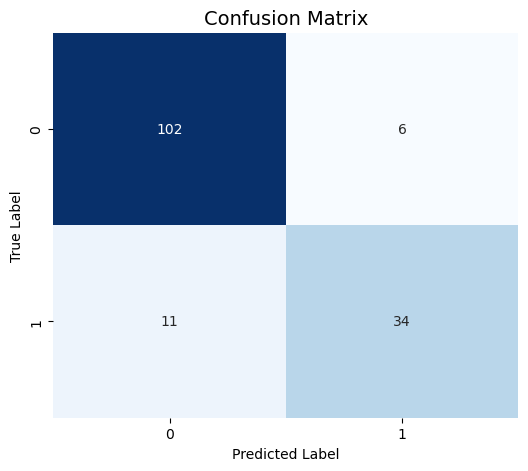

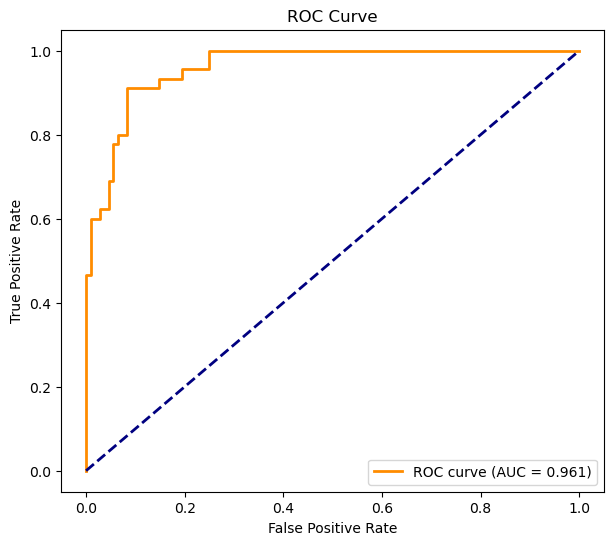

In [44]:
# Make predictions
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]  # probabilities for ROC-AUC

# Evaluate performance
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('./Plots/confusion_matrix.png')
plt.show()

# ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(False)
plt.savefig('./Plots/ROC_AUC_curve.png')
plt.show()


[1651]
        Gene  Coefficient  AbsCoefficient
391     GNLY     0.553825        0.553825
489    KLRF1     0.408316        0.408316
340  CYSLTR1     0.371402        0.371402
252     CD96     0.351164        0.351164
262   CLEC2D     0.314978        0.314978
29     RUNX3     0.313453        0.313453
457   CXCL11     0.307002        0.307002
108      ITK     0.296359        0.296359
169    TIGIT     0.261748        0.261748
351   CLEC2B     0.261040        0.261040
382   GIMAP2     0.254689        0.254689
22    IPCEF1     0.213254        0.213254
378     IL15     0.205663        0.205663
26    FAM26F     0.163892        0.163892
337    KLRC1     0.156240        0.156240
401    CASP1     0.135220        0.135220
247     TARP     0.114330        0.114330
30     KLRK1     0.085376        0.085376
106     CD72     0.062437        0.062437
434     EAF2     0.055610        0.055610


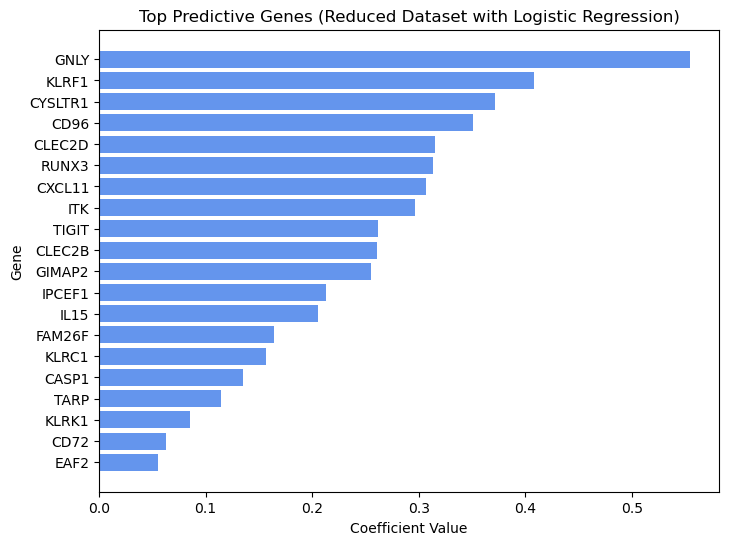

In [46]:
print(log_reg.n_iter_)

coef_df = pd.DataFrame({
    'Gene': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df['AbsCoefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False)

print(coef_df.head(20))  # top 20 predictive genes

top_genes = coef_df.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_genes['Gene'], top_genes['Coefficient'], color='cornflowerblue')
plt.xlabel("Coefficient Value")
plt.ylabel("Gene")
plt.title("Top Predictive Genes (Reduced Dataset with Logistic Regression)")
plt.gca().invert_yaxis()
plt.savefig('./Plots/top_predictive_genes.png')
plt.show()

In [39]:
print(coef_df['Gene'].head(20).to_list())  # top 20 predictive genes


['GNLY', 'KLRF1', 'CYSLTR1', 'CD96', 'CLEC2D', 'RUNX3', 'CXCL11', 'ITK', 'TIGIT', 'CLEC2B', 'GIMAP2', 'IPCEF1', 'IL15', 'FAM26F', 'KLRC1', 'CASP1', 'TARP', 'KLRK1', 'CD72', 'EAF2']


Top genes driving REJECTION:
        Gene  Coefficient
391     GNLY     0.553825
489    KLRF1     0.408316
340  CYSLTR1     0.371402
252     CD96     0.351164
262   CLEC2D     0.314978
29     RUNX3     0.313453
457   CXCL11     0.307002
108      ITK     0.296359
169    TIGIT     0.261748
351   CLEC2B     0.261040
382   GIMAP2     0.254689
22    IPCEF1     0.213254
378     IL15     0.205663
26    FAM26F     0.163892
337    KLRC1     0.156240

Top genes driving NON-REJECTION:
        Gene  Coefficient
453    TTC23    -0.016956
346  TNFAIP6    -0.013355


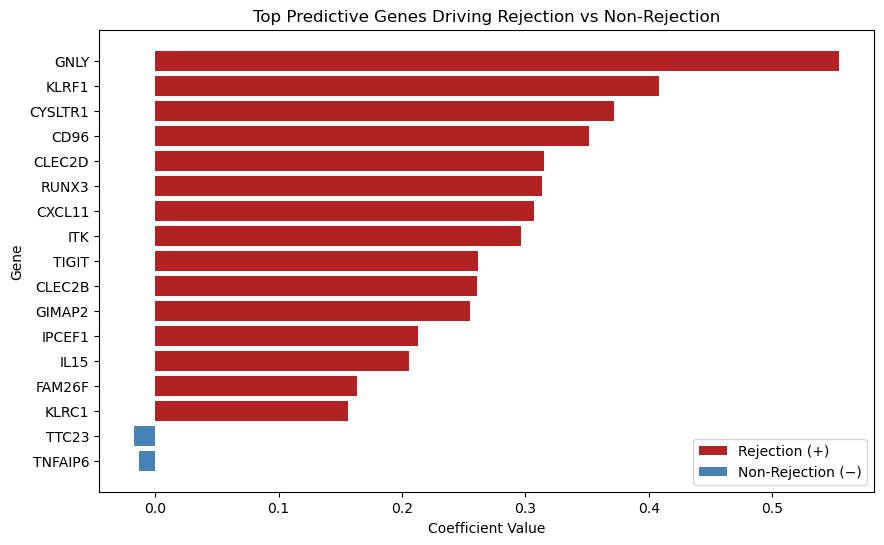

In [37]:
# Positive coefficients → predict class 1 (rejection)
rejection_genes = coef_df[coef_df['Coefficient'] > 0].head(15)

# Negative coefficients → predict class 0 (non-rejection)
non_rejection_genes = coef_df[coef_df['Coefficient'] < 0].head(15)

print("Top genes driving REJECTION:")
print(rejection_genes[['Gene', 'Coefficient']])

print("\nTop genes driving NON-REJECTION:")
print(non_rejection_genes[['Gene', 'Coefficient']])


plt.figure(figsize=(10,6))

plt.barh(
    rejection_genes['Gene'],
    rejection_genes['Coefficient'],
    color='firebrick',
    label='Rejection (+)'
)

plt.barh(
    non_rejection_genes['Gene'],
    non_rejection_genes['Coefficient'],
    color='steelblue',
    label='Non-Rejection (−)'
)

plt.xlabel("Coefficient Value")
plt.ylabel("Gene")
plt.title("Top Predictive Genes Driving Rejection vs Non-Rejection")
plt.legend()
plt.gca().invert_yaxis()
plt.show()
